Set up packages

In [9]:
library(Seurat)
library(Matrix)
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack




Make file paths

In [10]:
counts_path <- "geo_data/GSE182256_Export_counts.rds"
meta_path   <- "geo_data/GSE182256_Export_Metadata.txt.gz"

Load data

In [11]:
counts <- readRDS(counts_path)

meta <- read.delim(
  gzfile(meta_path),
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)

Align metadata to count matrix

In [13]:
# GEO export uses column X for cell barcodes
rownames(meta) <- meta$X

# Reorder metadata to match count matrix columns exactly
meta <- meta[colnames(counts), , drop = FALSE]

# Safety check
stopifnot(all(rownames(meta) == colnames(counts)))

Create Seurat object

In [14]:
obj <- CreateSeuratObject(
  counts = counts,
  meta.data = meta,
  project = "GSE182256"
)

print(obj)

An object of class Seurat 
19112 features across 77393 samples within 1 assay 
Active assay: RNA (19112 features, 0 variable features)
 1 layer present: counts


Normalize data

In [15]:
obj <- NormalizeData(obj, verbose = FALSE)

Create clean metadata columns

In [16]:
# Condition: Control1-6 = Sham, UUO1-2 = UUO
obj$condition <- ifelse(grepl("^Control", obj$orig.ident), "Sham", "UUO")

# Cleaned cell type labels from exported Cluster annotation
obj$celltype <- dplyr::recode(
  obj$Cluster,
  "B_Lymphocyte" = "B Lymph",
  "Profibrotic Tubules" = "Profib tubule",
  "Trans IC" = "Trans-IC",
  "Th17" = "TH17"
)

# Order cell types to resemble the paper / biological ordering
celltype_order <- c(
  "GEC", "Endo", "Podo", "PT",
  "Prolif PT", "Profib tubule",
  "ALOH", "DCT", "CNT", "CD PC",
  "A-IC", "Trans-IC", "B-IC",
  "Neutro", "Mono", "DC", "Macro", "pDC",
  "Baso",
  "B Lymph", "CD4 T", "Treg", "TH17",
  "NKT", "CD8 effector", "CD8 T", "NK",
  "Prolif Ly"
)

obj$celltype <- factor(obj$celltype, levels = celltype_order)
Idents(obj) <- "celltype"

Build plot

In [18]:
plot_df <- FetchData(
  obj,
  vars = c("celltype", "condition", genes_to_plot)
)

# Convert to long format
plot_long <- plot_df %>%
  pivot_longer(
    cols = all_of(genes_to_plot),
    names_to = "gene",
    values_to = "expr"
  )

# Summarize as:
# avg_exp = mean normalized expression
# pct_exp = percent of cells with expr > 0
dot_data <- plot_long %>%
  group_by(celltype, condition, gene) %>%
  summarise(
    avg_exp = mean(expr),
    pct_exp = mean(expr > 0) * 100,
    .groups = "drop"
  )

In [20]:
# Reverse order so the first label appears at top in ggplot
dot_data$celltype <- factor(dot_data$celltype, levels = rev(celltype_order))

# X axis order: Sham / UUO pairs for each gene
x_levels <- c(
  "Il4_Sham", "Il4_UUO",
  "Il6_Sham", "Il6_UUO",
  "Il18r1_Sham", "Il18r1_UUO",
  "Il1rl1_Sham", "Il1rl1_UUO"
)

dot_data$x_group <- factor(
  paste(dot_data$gene, dot_data$condition, sep = "_"),
  levels = x_levels
)

dot_data <- dot_data %>%
  group_by(gene) %>%
  mutate(avg_exp_scaled = rescale(avg_exp, to = c(0, 1))) %>%
  ungroup()

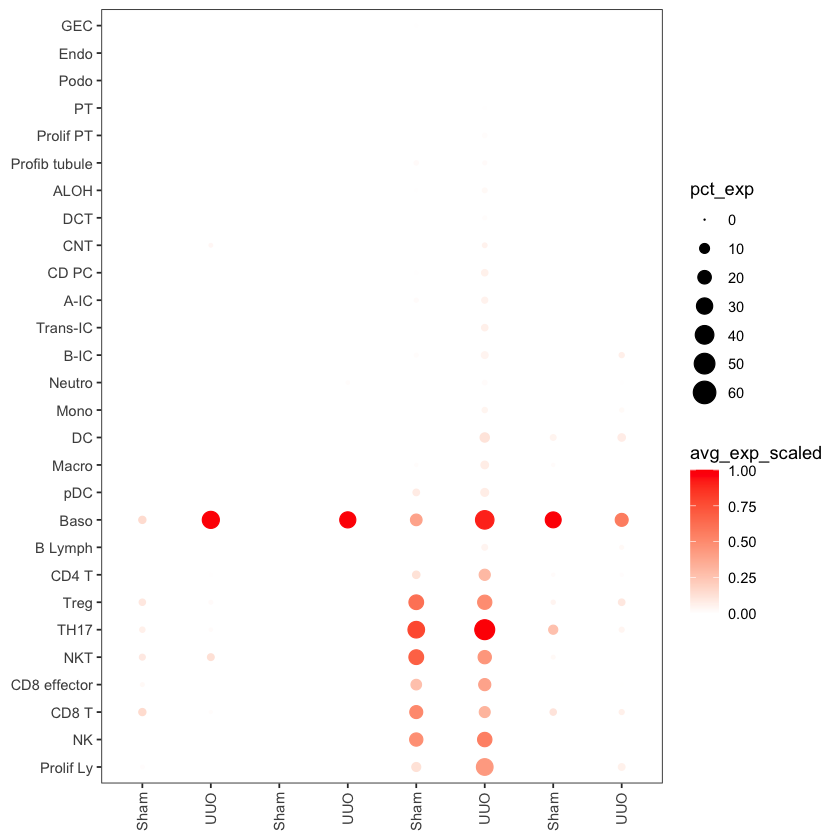

In [21]:
manual_plot <- ggplot(dot_data, aes(x = x_group, y = celltype)) +
  geom_point(aes(size = pct_exp, color = avg_exp_scaled)) +
  scale_color_gradient(low = "white", high = "red", name = "avg_exp_scaled") +
  scale_size(range = c(0, 6), limits = c(0, 60), name = "pct_exp") +
  scale_x_discrete(labels = c(
    "Sham", "UUO",
    "Sham", "UUO",
    "Sham", "UUO",
    "Sham", "UUO"
  )) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.title = element_blank(),
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)
  )

print(manual_plot)

In [23]:
print(dot_data %>% arrange(celltype, gene, condition))

# A tibble: 224 × 7
   celltype  condition gene   avg_exp pct_exp x_group     avg_exp_scaled
   <fct>     <chr>     <chr>    <dbl>   <dbl> <fct>                <dbl>
 1 Prolif Ly Sham      Il18r1 0.101     7.89  Il18r1_Sham        0.129  
 2 Prolif Ly UUO       Il18r1 0.341    31.6   Il18r1_UUO         0.434  
 3 Prolif Ly Sham      Il1rl1 0         0     Il1rl1_Sham        0      
 4 Prolif Ly UUO       Il1rl1 0.0381    3.95  Il1rl1_UUO         0.0604 
 5 Prolif Ly Sham      Il4    0.00531   0.658 Il4_Sham           0.00882
 6 Prolif Ly UUO       Il4    0         0     Il4_UUO            0      
 7 Prolif Ly Sham      Il6    0         0     Il6_Sham           0      
 8 Prolif Ly UUO       Il6    0         0     Il6_UUO            0      
 9 NK        Sham      Il18r1 0.378    19.1   Il18r1_Sham        0.481  
10 NK        UUO       Il18r1 0.431    22.8   Il18r1_UUO         0.549  
# ℹ 214 more rows


Figure 6d

In [24]:
genes_fig6d <- c("Il6st", "Il6ra")
genes_fig6d %in% rownames(obj)

[1] TRUE TRUE

In [25]:
plot_df_6d <- FetchData(
  obj,
  vars = c("celltype", "condition", genes_fig6d)
)

plot_long_6d <- plot_df_6d %>%
  pivot_longer(
    cols = all_of(genes_fig6d),
    names_to = "gene",
    values_to = "expr"
  )

dot_data_6d <- plot_long_6d %>%
  group_by(celltype, condition, gene) %>%
  summarise(
    avg_exp = mean(expr),
    pct_exp = mean(expr > 0) * 100,
    .groups = "drop"
  )

In [26]:
x_levels_6d <- c(
  "Il6st_Sham", "Il6st_UUO",
  "Il6ra_Sham", "Il6ra_UUO"
)

dot_data_6d$x_group <- factor(
  paste(dot_data_6d$gene, dot_data_6d$condition, sep = "_"),
  levels = x_levels_6d
)

dot_data_6d <- dot_data_6d %>%
  group_by(gene) %>%
  mutate(avg_exp_scaled = scales::rescale(avg_exp, to = c(0, 1))) %>%
  ungroup()

In [30]:
celltype_order <- c(
  "GEC", "Endo", "Podo", "PT",
  "Prolif PT", "Profib tubule",
  "ALOH", "DCT", "CNT", "CD PC",
  "A-IC", "Trans-IC", "B-IC",
  "Neutro", "Mono", "DC", "Macro", "pDC",
  "Baso",
  "B Lymph", "CD4 T", "Treg", "TH17",
  "NKT", "CD8 effector", "CD8 T", "NK",
  "Prolif Ly"
)

dot_data_6d$celltype <- factor(dot_data_6d$celltype, levels = rev(celltype_order))

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


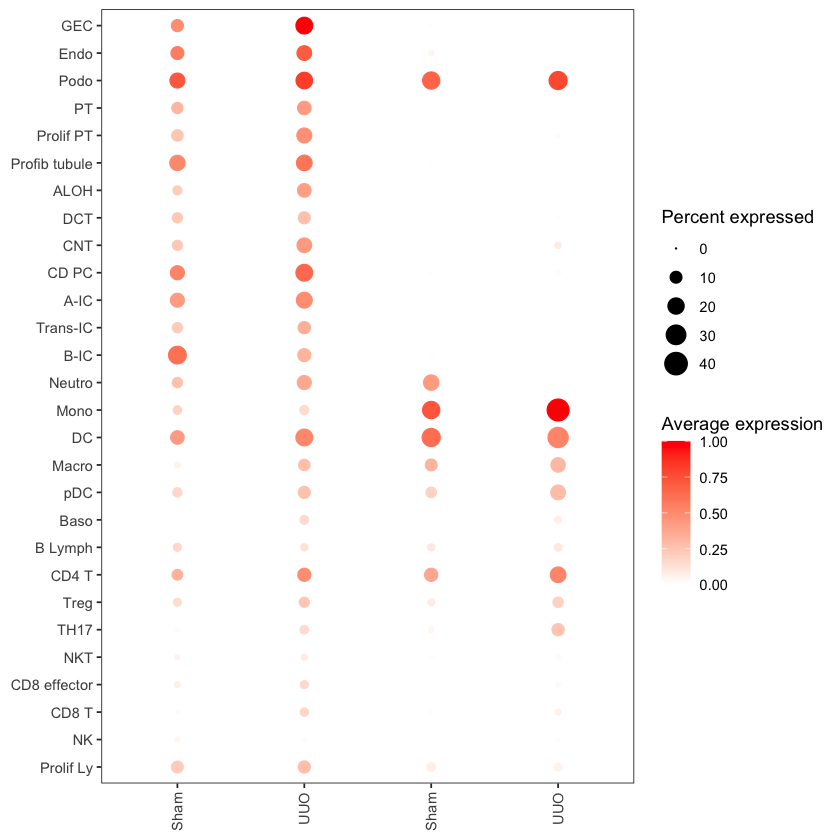

In [31]:
fig6d_plot <- ggplot(dot_data_6d, aes(x = x_group, y = celltype)) +
  geom_point(aes(size = pct_exp, color = avg_exp_scaled)) +
  scale_color_gradient(low = "white", high = "red", name = "Average expression") +
  scale_size(range = c(0, 6), limits = c(0, 40), name = "Percent expressed") +
  scale_x_discrete(labels = c("Sham", "UUO", "Sham", "UUO")) +
  theme_bw() +
  theme(
    panel.grid = element_blank(),
    axis.title = element_blank(),
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)
  )

fig6d_plot